Accuracy: 0.9760981912144703

Classification Report:
               precision    recall  f1-score   support

    Abnormal       0.96      0.78      0.86       300
      Normal       0.98      1.00      0.99      2796

    accuracy                           0.98      3096
   macro avg       0.97      0.89      0.93      3096
weighted avg       0.98      0.98      0.97      3096



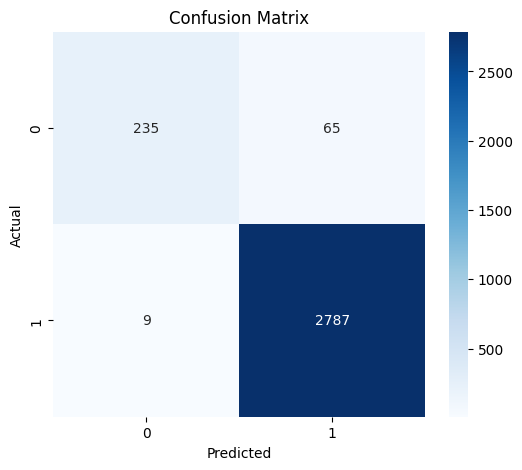

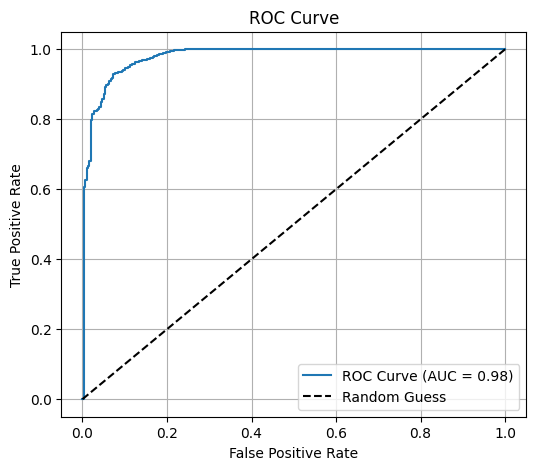

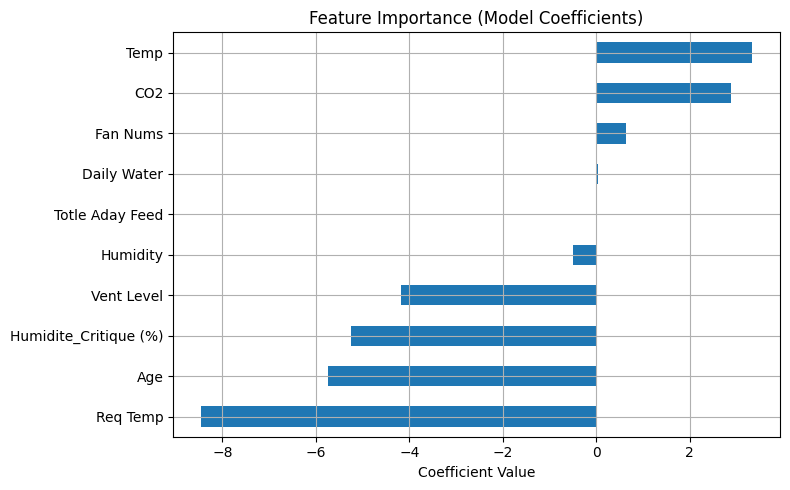

In [ ]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc
)
from sklearn.preprocessing import StandardScaler, label_binarize

# Load dataset
df = pd.read_csv('/content/5_with_status.csv')

# Prepare features and target
X = df.drop(columns=['Status', 'Unnamed: 0'])  # Drop target and index
y = df['Status']

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC Curve (binary classification)
if len(y.unique()) == 2:
    y_test_bin = label_binarize(y_test, classes=[y.min(), y.max()]).ravel()
    y_scores = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_bin, y_scores)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label='ROC Curve (AUC = {:.2f})'.format(roc_auc))
    plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.grid(True)
    plt.show()

# === 3. Feature Importance (Coefficients) ===
coefficients = pd.Series(model.coef_[0], index=df.columns.drop(['Status', 'Unnamed: 0']))
plt.figure(figsize=(8, 5))
coefficients.sort_values().plot(kind='barh')
plt.title('Feature Importance (Model Coefficients)')
plt.xlabel('Coefficient Value')
plt.grid(True)
plt.tight_layout()
plt.show()


Accuracy: 0.9760981912144703

Classification Report:
               precision    recall  f1-score   support

    Abnormal       0.96      0.78      0.86       300
      Normal       0.98      1.00      0.99      2796

    accuracy                           0.98      3096
   macro avg       0.97      0.89      0.93      3096
weighted avg       0.98      0.98      0.97      3096



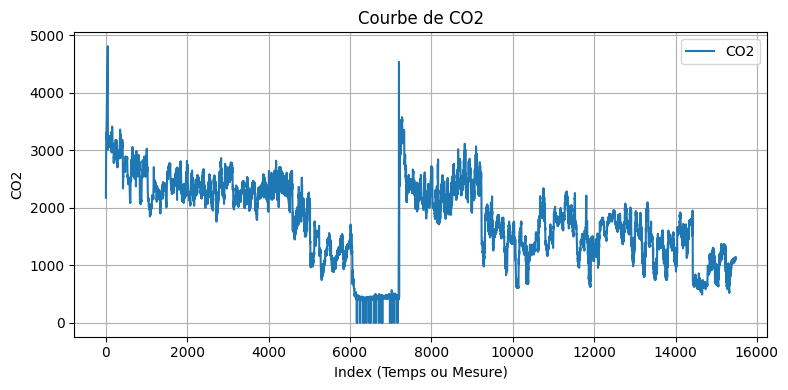

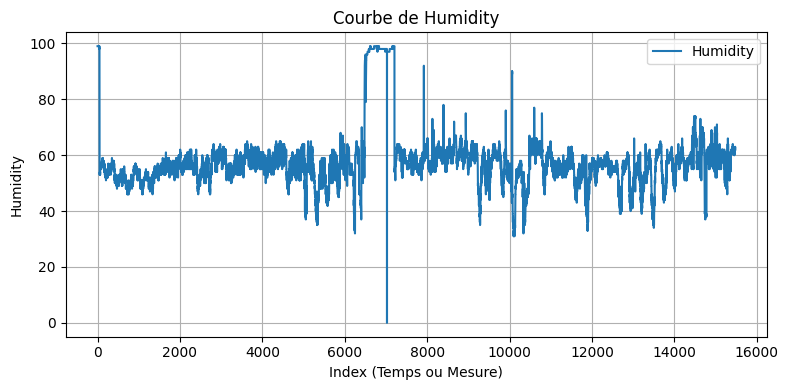

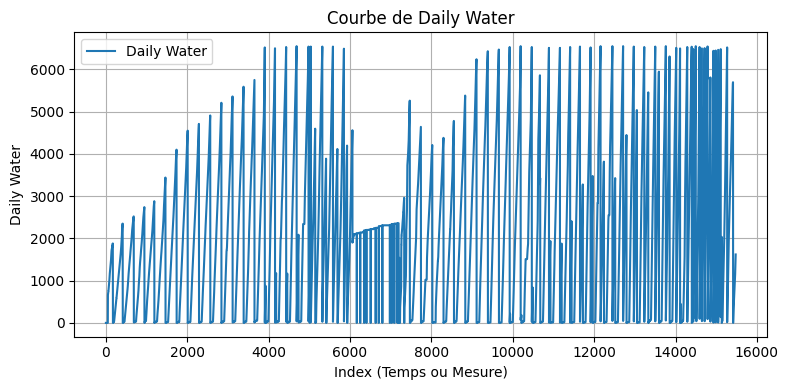

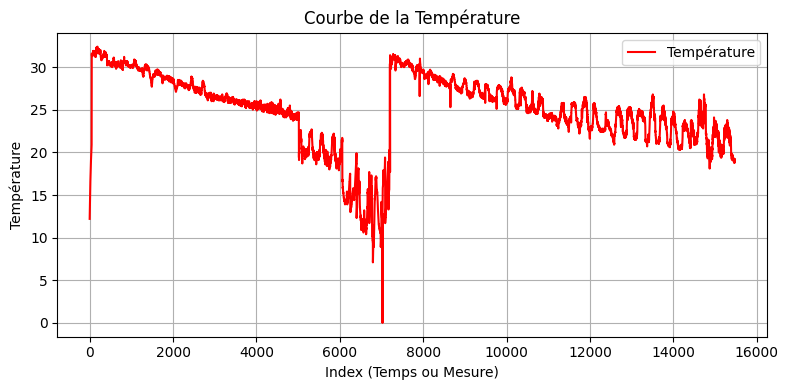

In [ ]:
# === 1. Import des bibliothèques nécessaires ===
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report
)
from sklearn.preprocessing import StandardScaler

# === 2. Chargement des données ===
df = pd.read_csv('/content/5_with_status.csv')

# === 3. Préparation des données ===
X = df.drop(columns=['Status', 'Unnamed: 0'])  # Supprimer la cible et l'index
y = df['Status']

# === 4. Normalisation des features ===
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# === 5. Division en train/test ===
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# === 6. Entraînement du modèle ===
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# === 7. Prédictions et précision ===
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# === 8. Affichage des courbes une par une (hors temperature) ===
columns_to_plot = ['CO2', 'Humidity', 'Daily Water']  # sans 'Temperature'
for col in columns_to_plot:
    if col in df.columns:
        plt.figure(figsize=(8, 4))
        plt.plot(df.index, df[col], label=col, color='tab:blue')
        plt.title(f'Courbe de {col}')
        plt.xlabel('Index (Temps ou Mesure)')
        plt.ylabel(col)
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

# === Courbe de la Température ===
plt.figure(figsize=(8, 4))
plt.plot(df.index, df['Temp'], label='Température', color='red')
plt.title('Courbe de la Température')
plt.xlabel('Index (Temps ou Mesure)')
plt.ylabel('Température')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

